## Environment Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from xgboost import XGBRegressor

## Loading the Dataset and Preprocessing



In [ ]:
df = pd.read_csv("data/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## Handling Missing Data

In [ ]:
y = df["SalePrice"]
X = df.drop(columns=["SalePrice", "Id"] ).copy()

In [ ]:
missing_summary = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .to_frame(name="missing_fraction")
)

missing_summary.head(20)

,missing_fraction
PoolQC,0.995205
MiscFeature,0.963014
Alley,0.937671
Fence,0.807534
MasVnrType,0.597260
FireplaceQu,0.472603
LotFrontage,0.177397
GarageQual,0.055479
GarageFinish,0.055479
GarageType,0.055479


In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing
y = np.log1p(df["SalePrice"])
X = df.drop(columns=["SalePrice", "Id"]).copy()

cols_to_drop = ["PoolQC", "MiscFeature", "Alley"]
X.drop(columns=cols_to_drop, inplace=True)

## Choosing a Target Variable

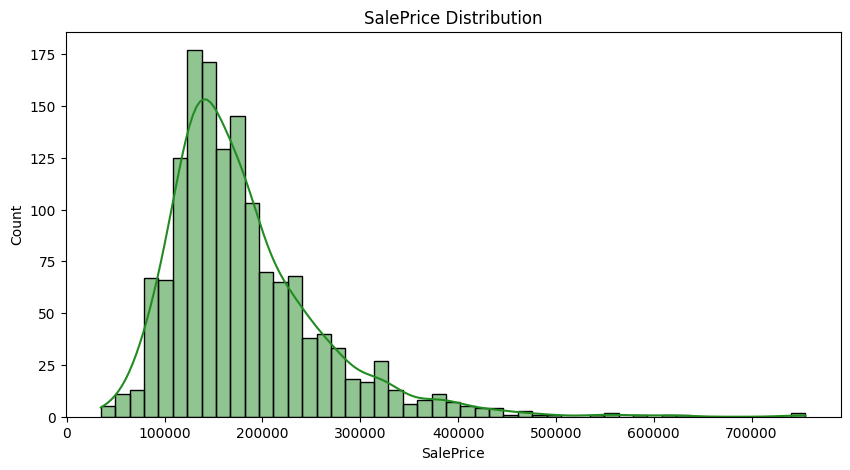

Skew: 1.8828757597682129


In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df["SalePrice"], kde=True, color = "forestgreen")
plt.title("SalePrice Distribution")
plt.show()

print("Skew:", df["SalePrice"].skew())

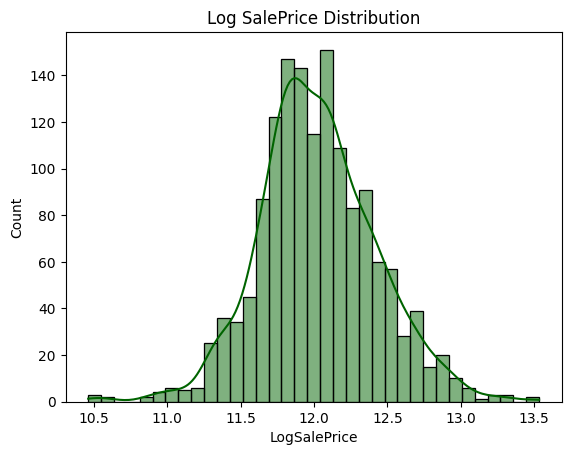

In [ ]:
df["LogSalePrice"] = np.log1p(df["SalePrice"])

sns.histplot(df["LogSalePrice"], kde=True, color = "darkgreen")
plt.title("Log SalePrice Distribution")
plt.show()

## Encoding Ordinal Features

In [ ]:
# Quality-based ordinal features
qual_map = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

ordinal_qual_cols = [
    "ExterQual", "ExterCond",
    "BsmtQual", "BsmtCond",
    "HeatingQC", "KitchenQual",
    "FireplaceQu", "GarageQual",
    "GarageCond"
]

for col in ordinal_qual_cols:
    X[col] = X[col].map(qual_map)

# Fence quality
fence_map = {"MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4}
X["Fence"] = X["Fence"].map(fence_map)

# Basement exposure
bsmt_exposure_map = {"No": 1, "Mn": 2, "Av": 3, "Gd": 4}
X["BsmtExposure"] = X["BsmtExposure"].map(bsmt_exposure_map)

# Basement finish types
bsmt_fin_map = {
    "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6
}
X["BsmtFinType1"] = X["BsmtFinType1"].map(bsmt_fin_map)
X["BsmtFinType2"] = X["BsmtFinType2"].map(bsmt_fin_map)

# Garage finish
garage_finish_map = {"Unf": 1, "RFn": 2, "Fin": 3}
X["GarageFinish"] = X["GarageFinish"].map(garage_finish_map)

# Functional utility
functional_map = {
    "Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8
}
X["Functional"] = X["Functional"].map(functional_map)

In [ ]:
# Identify feature types after encoding
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numeric / Ordinal Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numeric / Ordinal Features:
Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual', 'ExterCond',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'HeatingQC',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageYrBlt', 'GarageFinish', 'GarageCars',
       'GarageArea', 'GarageQual', 'GarageCond', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'Fence',
       'MiscVal', 'MoSold', 'YrSold'],
      dtype='object')

Categorical Features:
Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Conditio

## Correlation Matrix of Numeric and Ordinal Features

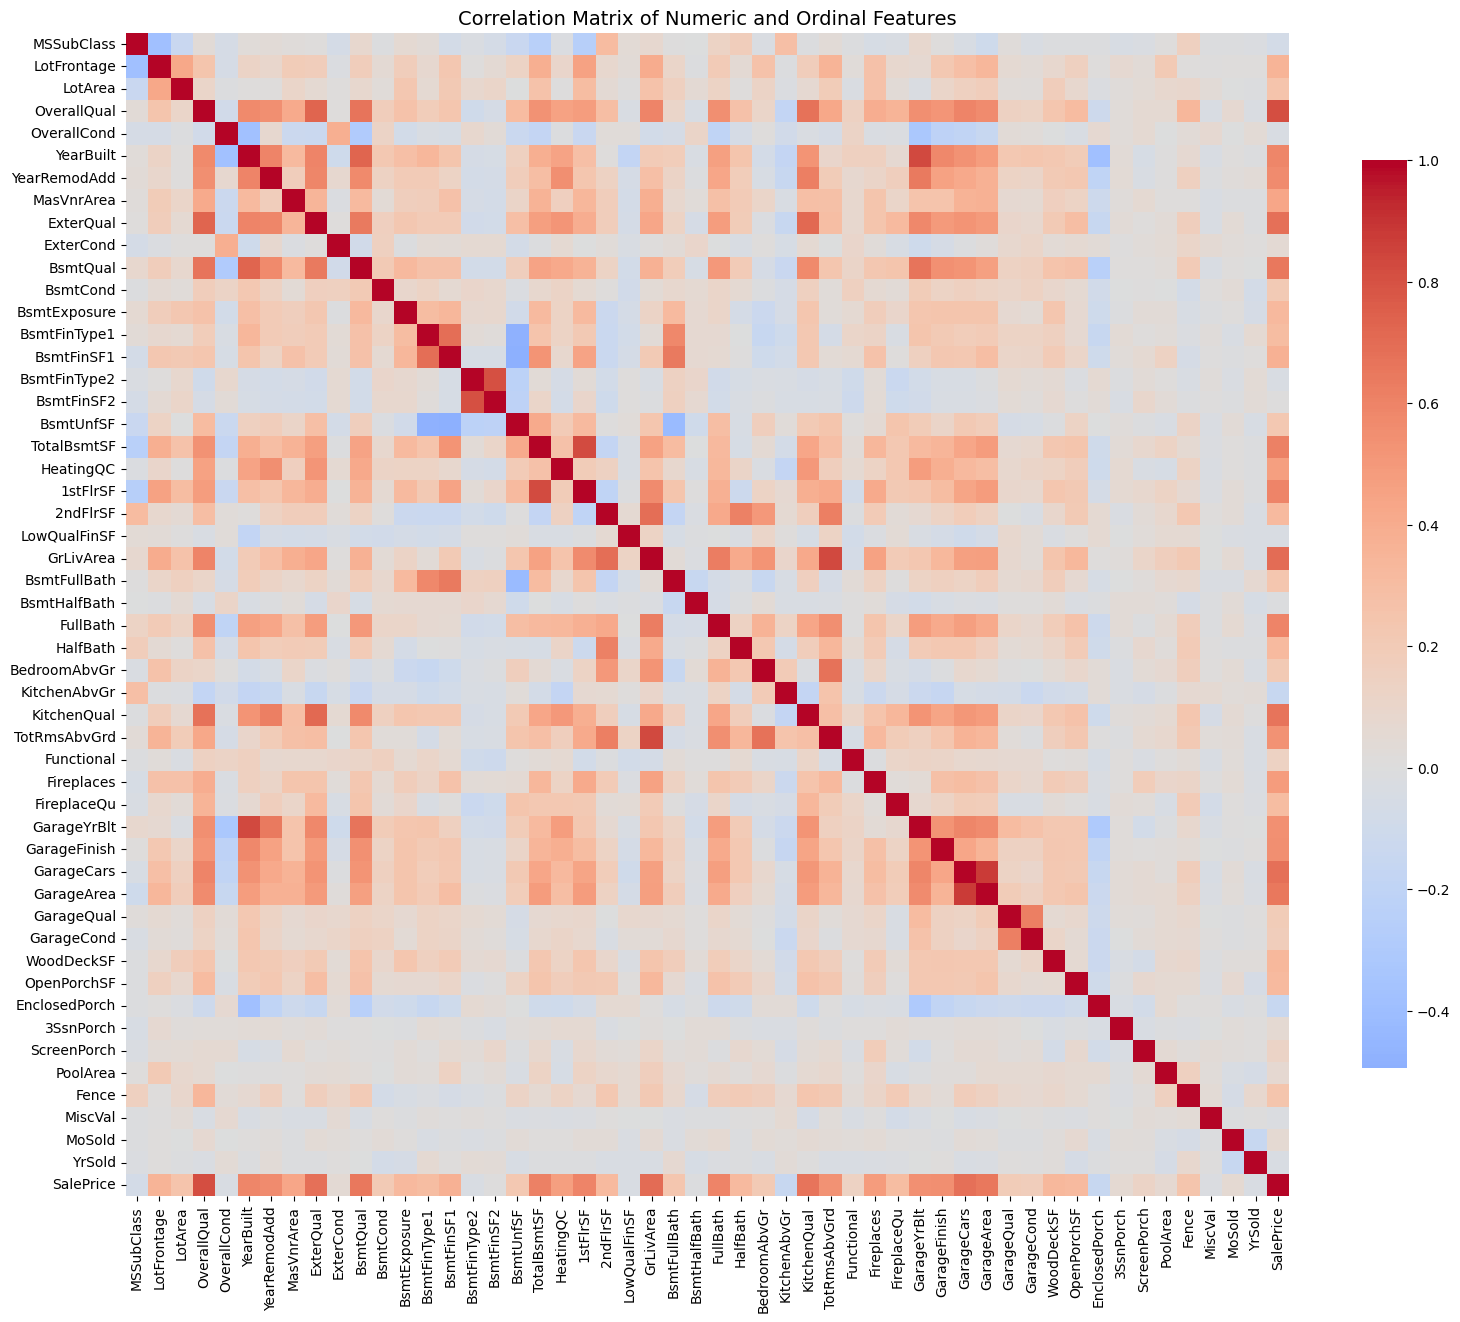

In [ ]:
corr_df = X[numeric_features].copy()
corr_df["SalePrice"] = y

corr_matrix = corr_df.corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.7}
)
plt.title("Correlation Matrix of Numeric and Ordinal Features", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
corr_with_price = (corr_df.corr()["SalePrice"].sort_values(ascending=False))

## Top 10 Features Most Correlated with SalePrice

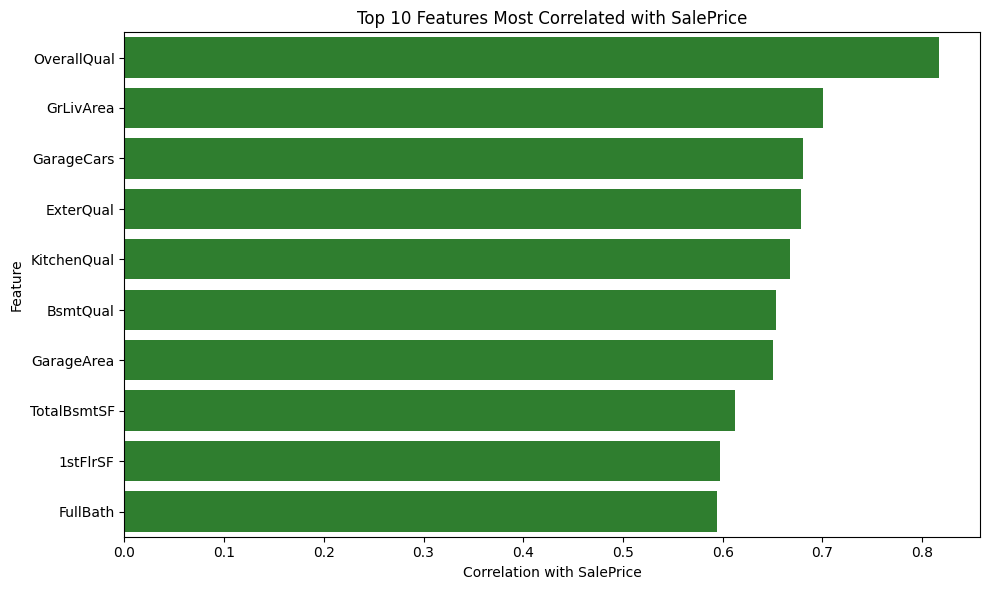

In [ ]:
# Select top 10 features most correlated with SalePrice (excluding SalePrice itself)
top10_corr = corr_with_price.drop("SalePrice").head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top10_corr.values,
    y=top10_corr.index,
    color="forestgreen"
)

plt.title("Top 10 Features Most Correlated with SalePrice")
plt.xlabel("Correlation with SalePrice")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## OverallQual vs Log SalePrice

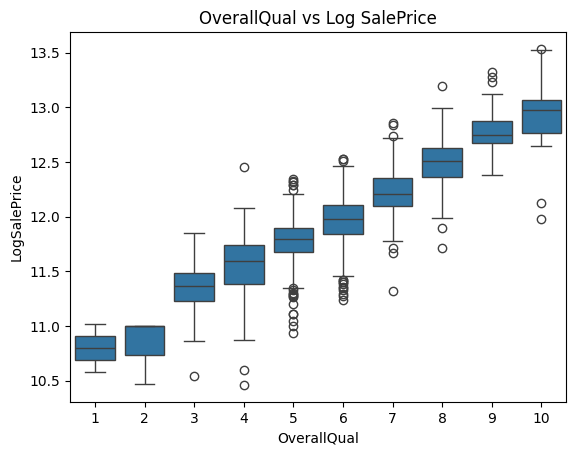

In [ ]:
sns.boxplot(x="OverallQual", y="LogSalePrice", data=df)
plt.title("OverallQual vs Log SalePrice")
plt.show()


## GrLivArea vs Log SalePrice

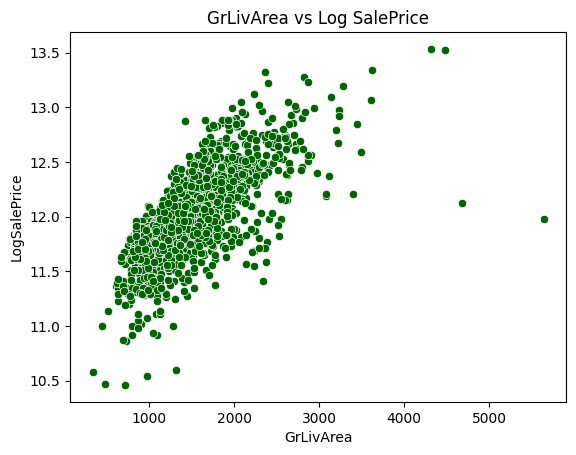

In [ ]:
sns.scatterplot(x="GrLivArea", y="LogSalePrice", data=df, color ="darkgreen")
plt.title("GrLivArea vs Log SalePrice")
plt.show()


## Fireplaces vs Log Sale Price

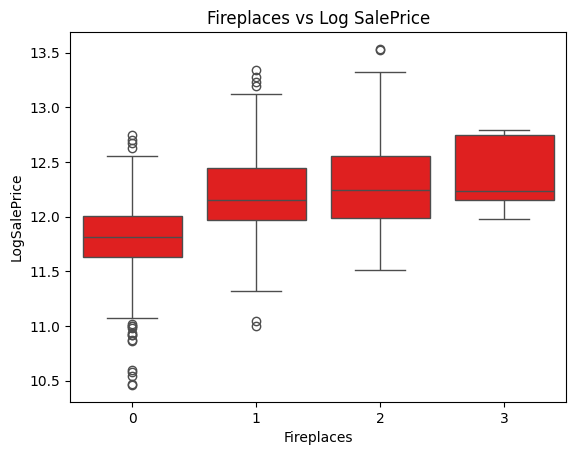

In [ ]:
sns.boxplot(x="Fireplaces", y="LogSalePrice", data=df, color ="red")
plt.title("Fireplaces vs Log SalePrice")
plt.show()

## LASSO Regression and Hyperparameter Tuning


In [ ]:
# cells dropped due to na values
cols_to_drop_lasso = [
    "Fence",
    "FireplaceQu",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "GarageYrBlt",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]


In [ ]:
X_lasso = X.drop(columns=cols_to_drop_lasso)


In [ ]:
numeric_features_lasso = X_lasso.select_dtypes(
    include=["int64", "float64"]
).columns

X_numeric = X_lasso[numeric_features_lasso].copy()


In [ ]:
X_numeric = X_numeric.fillna(X_numeric.median())


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train_scaled, y_train)


Lasso(alpha=0.01, max_iter=10000)

In [ ]:
lasso_coef = pd.Series(lasso.coef_, index=X_numeric.columns)

selected_features = lasso_coef[lasso_coef != 0].sort_values(
    key=abs, ascending=False
)

selected_features


,0
OverallQual,0.113755
GrLivArea,0.094794
GarageCars,0.064020
YearBuilt,0.061625
Fireplaces,0.032542
BsmtFullBath,0.028363
OverallCond,0.028355
MSSubClass,-0.024240
YearRemodAdd,0.018027
KitchenQual,0.016852


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----------------------------
# TEST SET METRICS
# ----------------------------
lasso_test_preds = lasso.predict(X_test_scaled)

lasso_test_mse = mean_squared_error(y_test, lasso_test_preds)
lasso_test_rmse = lasso_test_mse ** 0.5
lasso_test_mae = mean_absolute_error(y_test, lasso_test_preds)
lasso_test_r2 = r2_score(y_test, lasso_test_preds)

print("📈 LASSO Test Results")
print("-----------------------------")
print("Test RMSE:", lasso_test_rmse)
print("Test MAE:", lasso_test_mae)
print("Test R²:", lasso_test_r2)

# ----------------------------
# TRAINING SET METRICS
# ----------------------------
lasso_train_preds = lasso.predict(X_train_scaled)

lasso_train_mse = mean_squared_error(y_train, lasso_train_preds)
lasso_train_rmse = lasso_train_mse ** 0.5
lasso_train_mae = mean_absolute_error(y_train, lasso_train_preds)
lasso_train_r2 = r2_score(y_train, lasso_train_preds)

print("\n📉 LASSO Training Results")
print("-----------------------------")
print("Train RMSE:", lasso_train_rmse)
print("Train MAE:", lasso_train_mae)
print("Train R²:", lasso_train_r2)


📈 LASSO Test Results
-----------------------------
Test RMSE: 0.14780360893441663
Test MAE: 0.10613490561073192
Test R²: 0.8712249515588713

📉 LASSO Training Results
-----------------------------
Train RMSE: 0.14799260958907487
Train MAE: 0.09949327554518046
Train R²: 0.8587013039316942


## Lasso Generalizability

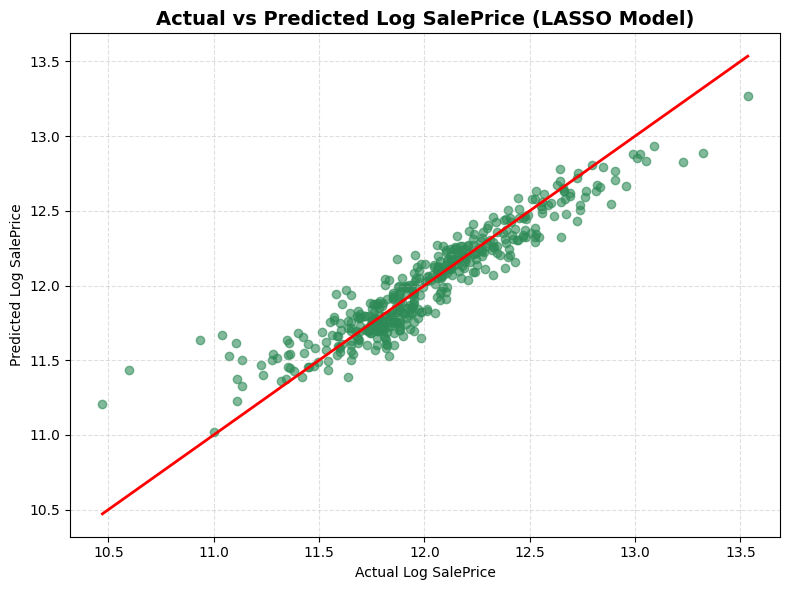

In [ ]:
lasso_test_preds = lasso.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, lasso_test_preds, alpha=0.6, color="#2E8B57")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2)

plt.title("Actual vs Predicted Log SalePrice (LASSO Model)", fontsize=14, weight="bold")
plt.xlabel("Actual Log SalePrice")
plt.ylabel("Predicted Log SalePrice")

plt.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## Gradient Boosting (XGBoost)

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# XGBoost model
xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.015,
    max_depth=3,
    min_child_depth = 10,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

mse = mean_squared_error(y_test, xgb_preds)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, xgb_preds)
r2 = r2_score(y_test, xgb_preds)
print("📈 XGBoost Results")
print("-----------------------------")
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

train_preds = xgb.predict(X_train)

train_mse = mean_squared_error(y_train, train_preds)
train_rmse = train_mse ** 0.5
train_mae = mean_absolute_error(y_train, train_preds)
train_r2 = r2_score(y_train, train_preds)

print("\n📉 XGBoost Training Results")
print("-----------------------------")
print("Train RMSE:", train_rmse)
print("Train MAE:", train_mae)
print("Train R²:", train_r2)








/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:16:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "min_child_depth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📈 XGBoost Results
-----------------------------
RMSE: 0.13140490190111362
MAE: 0.08875825675406702
R²: 0.8982147663657044

📉 XGBoost Training Results
-----------------------------
Train RMSE: 0.07853670834859129
Train MAE: 0.05641851707844682
Train R²: 0.9602072926755428


In [ ]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Display top 15 features
xgb_importance.head(15)

,Feature,Importance
3,OverallQual,0.256433
8,ExterQual,0.141038
25,KitchenQual,0.133423
29,GarageCars,0.098813
18,GrLivArea,0.070124
28,Fireplaces,0.036670
13,TotalBsmtSF,0.027495
6,YearRemodAdd,0.022391
10,BsmtFinSF1,0.019466
5,YearBuilt,0.017433


## XGBoost Generalizability

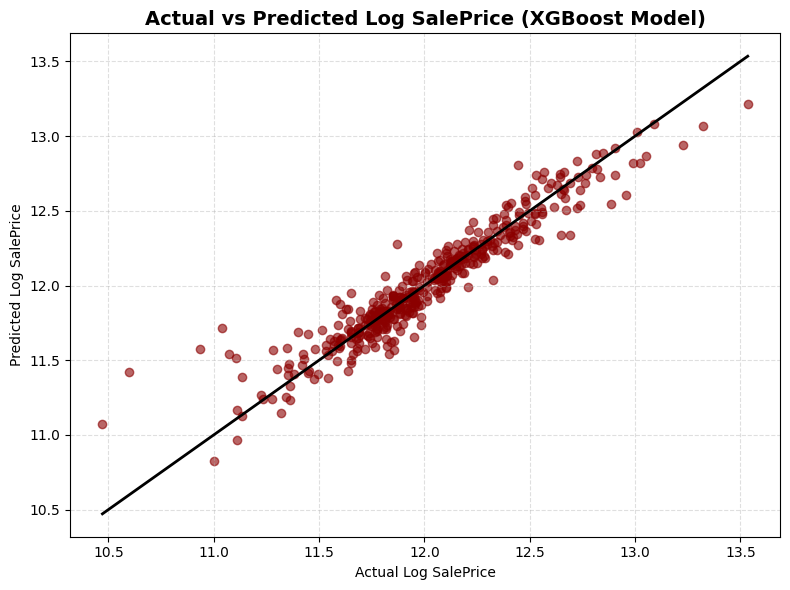

In [ ]:
xgb_preds = xgb.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, xgb_preds, alpha=0.6, color="#8B0000")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="black", linewidth=2)

plt.title("Actual vs Predicted Log SalePrice (XGBoost Model)", fontsize=14, weight="bold")
plt.xlabel("Actual Log SalePrice")
plt.ylabel("Predicted Log SalePrice")
plt.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


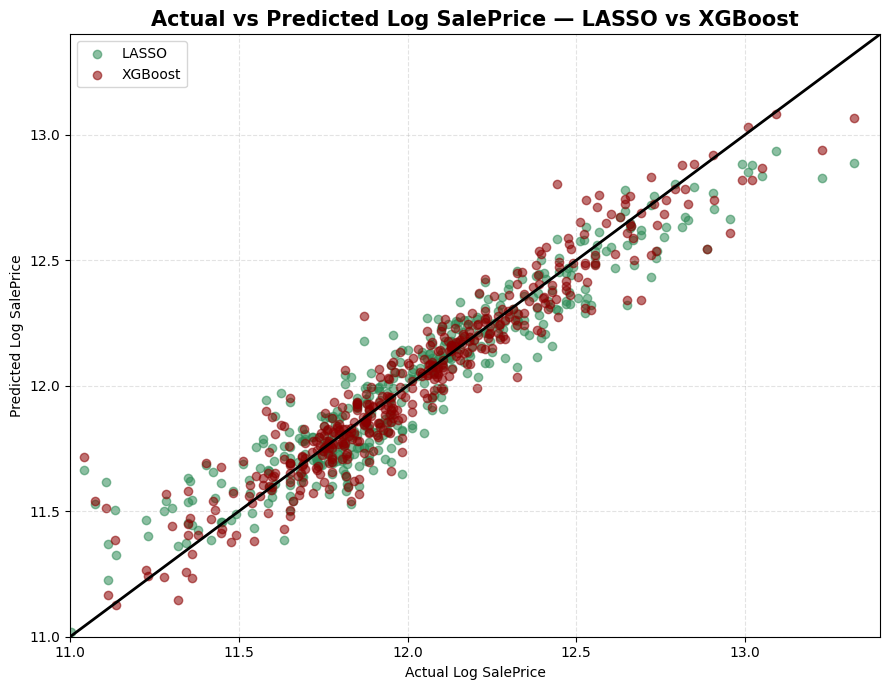

In [ ]:
plt.figure(figsize=(9, 7))

# LASSO
plt.scatter(
    y_test,
    lasso_test_preds,
    alpha=0.55,
    color="#2E8B57",
    label="LASSO"
)

# XGBoost
plt.scatter(
    y_test,
    xgb_preds,
    alpha=0.55,
    color="#8B0000",
    label="XGBoost"
)

# Reference diagonal
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="black",
    linewidth=2
)

plt.title(
    "Actual vs Predicted Log SalePrice — LASSO vs XGBoost",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Actual Log SalePrice")
plt.ylabel("Predicted Log SalePrice")
plt.legend()

# 🔍 Zoom to show main relationship clearly
plt.xlim(11.0, 13.4)
plt.ylim(11.0, 13.4)

plt.grid(linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()
